## Google colab GPU

In [1]:
# Colab: clone repo + add to path
import os
import sys
import subprocess

IN_COLAB = 'google.colab' in sys.modules
REPO_URL = 'https://github.com/colinminini/LLM6G-Repository'
REPO_DIR = 'LLM6G-Repository'

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.check_call(['git', 'clone', REPO_URL])
    os.chdir(REPO_DIR)
    if os.getcwd() not in sys.path:
        sys.path.insert(0, os.getcwd())
else:
    print('Repo clone skipped (not running in Colab).')

HAS_CUDA = False
try:
    import torch
    HAS_CUDA = torch.cuda.is_available()
except Exception:
    pass

if IN_COLAB and HAS_CUDA:
    # Install dependencies only when running on Colab with GPU
    !pip -q install -U pip
    !pip -q install -r requirements.txt
    # Optional: verify GPU
    !nvidia-smi
else:
    print(f'GPU setup skipped (colab={IN_COLAB}, cuda={HAS_CUDA}).')


Repo clone skipped (not running in Colab).
GPU setup skipped (colab=False, cuda=False).


# Model Benchmarking (Coverage)

Train LSTM, DeepAR, and TFT on `data_1to7`, then fine-tune Chronos-2 on the same dataset. The summary reports coverage on train/val/test and plots the 0.8 one-step coverage target.


In [2]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from scripts.train_utils import train_all
from scripts.chronos2_finetune import (
    Chronos2FineTuneConfig,
    build_default_hyperparameters,
    load_splits_for_autogluon,
    run_chronos2_finetune,
    evaluate_chronos2_models,
)

MODEL_TYPES = ["lstm", "deepar", "tft"]
DATASET = "data_1to7"
SPLITS = ["train", "val", "test"]

CONTEXT_LENGTH = 64
FORECAST_LENGTH = 16
QUANTILES = (0.1, 0.5, 0.9)
MAX_EPOCHS = 100
PATIENCE = 3
HIDDEN_SIZE = 128
NUM_LAYERS = 2
NUM_HEADS = 4
COVERAGE_TARGET = 0.8

AUTOGLUON_TIME_LIMIT = 3000  # seconds
AUTOGLUON_EVAL_METRIC = "RMSE"
AUTOGLUON_FREQ = "s"  # synthetic regular cadence
AUTOGLUON_KNOWN_COVARIATES = []

RESULTS_DIR = Path("results/benchmarks")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

CHRONOS2_CONFIG = Chronos2FineTuneConfig(
    dataset_base=DATASET,
    prediction_length=FORECAST_LENGTH,
    quantiles=QUANTILES,
    freq=AUTOGLUON_FREQ,
    use_integer_timestamps=True,
    synthetic_start="2000-01-01 00:00:00",
    eval_metric=AUTOGLUON_EVAL_METRIC,
    time_limit=AUTOGLUON_TIME_LIMIT,
    known_covariates_names=AUTOGLUON_KNOWN_COVARIATES,
    results_dir=RESULTS_DIR,
    #hyperparameters=build_default_hyperparameters(),
    hyperparameters={"Chronos2": [
            {"ag_args": {"name_suffix": "ZeroShot"},
             "context_length": CONTEXT_LENGTH},
            {"fine_tune": True, "ag_args": {"name_suffix": "FineTuned"},
             "context_length": CONTEXT_LENGTH},
        ]},

)


## Train baseline models

This runs LSTM, DeepAR, and TFT on `data_1to7`. Coverage shown is the final epoch value returned by the trainer.


In [3]:
train_results, train_histories = train_all(
    MODEL_TYPES,
    DATASET,
    context_length=CONTEXT_LENGTH,
    forecast_length=FORECAST_LENGTH,
    quantiles=QUANTILES,
    max_epochs=MAX_EPOCHS,
    patience=PATIENCE,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    num_heads=NUM_HEADS,
)

train_rows = []
for (dataset, model), metrics in train_results.items():
    for split, coverage in metrics.items():
        train_rows.append(
            {"dataset": dataset, "split": split, "model": model, "coverage": coverage}
        )

train_df = pd.DataFrame(train_rows)
train_pivot = train_df.pivot_table(
    index=["dataset", "split"], columns="model", values="coverage"
).sort_index()
train_pivot


Epoch 1/100 - train_loss=0.508 - train_rmse=3.641 - val_loss=0.785 - val_rmse=5.690 - test_loss=0.912 - test_rmse=6.786 
Epoch 2/100 - train_loss=0.458 - train_rmse=3.527 - val_loss=0.762 - val_rmse=5.021 - test_loss=0.872 - test_rmse=6.053 
Epoch 3/100 - train_loss=0.439 - train_rmse=3.077 - val_loss=0.727 - val_rmse=4.646 - test_loss=0.816 - test_rmse=5.473 
Epoch 4/100 - train_loss=0.431 - train_rmse=3.041 - val_loss=0.715 - val_rmse=4.675 - test_loss=0.807 - test_rmse=5.544 
Epoch 5/100 - train_loss=0.429 - train_rmse=3.029 - val_loss=0.714 - val_rmse=4.675 - test_loss=0.808 - test_rmse=5.478 
Epoch 6/100 - train_loss=0.427 - train_rmse=3.013 - val_loss=0.711 - val_rmse=4.612 - test_loss=0.806 - test_rmse=5.383 
Epoch 7/100 - train_loss=0.424 - train_rmse=3.017 - val_loss=0.711 - val_rmse=4.668 - test_loss=0.800 - test_rmse=5.425 
Early stopping at epoch 8: train_rmse=3.033, val_rmse=4.637, test_rmse=5.368


'Final metrics'

,metric,value
0,train_loss,0.424
1,train_rmse,3.033
2,val_loss,0.710
3,val_rmse,4.637
4,train_q0.1,0.175
5,train_q0.5,0.784
6,train_q0.9,0.315
7,val_q0.1,0.295
8,val_q0.5,1.315
9,val_q0.9,0.537


Epoch 1/100 - train_loss=1.711 - train_rmse=2.590 - val_loss=2.172 - val_rmse=3.926 - test_loss=2.205 - test_rmse=4.485 
Epoch 2/100 - train_loss=1.584 - train_rmse=2.434 - val_loss=2.117 - val_rmse=3.862 - test_loss=2.149 - test_rmse=4.414 
Epoch 3/100 - train_loss=1.566 - train_rmse=2.416 - val_loss=2.120 - val_rmse=3.873 - test_loss=2.148 - test_rmse=4.395 
Epoch 4/100 - train_loss=1.553 - train_rmse=2.404 - val_loss=2.122 - val_rmse=3.876 - test_loss=2.153 - test_rmse=4.407 
Epoch 5/100 - train_loss=1.544 - train_rmse=2.397 - val_loss=2.120 - val_rmse=3.861 - test_loss=2.157 - test_rmse=4.416 
Epoch 6/100 - train_loss=1.527 - train_rmse=2.388 - val_loss=2.112 - val_rmse=3.886 - test_loss=2.137 - test_rmse=4.419 
Early stopping at epoch 7: train_rmse=2.383, val_rmse=3.898, test_rmse=4.401


'Final metrics'

,metric,value
0,train_loss,1.509
1,train_rmse,2.383
2,val_loss,2.097
3,val_rmse,3.898
4,train_q0.1,0.238
5,train_q0.5,0.757
6,train_q0.9,0.293
7,val_q0.1,0.408
8,val_q0.5,1.285
9,val_q0.9,0.504


Epoch 1/100 - train_loss=0.463 - train_rmse=3.257 - val_loss=0.730 - val_rmse=4.744 - test_loss=0.838 - test_rmse=5.676 
Epoch 2/100 - train_loss=0.432 - train_rmse=3.028 - val_loss=0.721 - val_rmse=4.633 - test_loss=0.813 - test_rmse=5.356 
Epoch 3/100 - train_loss=0.427 - train_rmse=3.019 - val_loss=0.712 - val_rmse=4.673 - test_loss=0.803 - test_rmse=5.338 
Early stopping at epoch 4: train_rmse=3.032, val_rmse=4.634, test_rmse=5.373


'Final metrics'

,metric,value
0,train_loss,0.424
1,train_rmse,3.032
2,val_loss,0.713
3,val_rmse,4.634
4,train_q0.1,0.175
5,train_q0.5,0.780
6,train_q0.9,0.318
7,val_q0.1,0.296
8,val_q0.5,1.295
9,val_q0.9,0.565


model              deepar      lstm       tft
dataset   split                              
data_1to7 test   0.858446  0.743903  0.386265
          train  0.850372  0.799359  0.799838
          val    0.857255  0.764353  0.393512

## AutoGluon Chronos-2 fine-tuning

We fine-tune Chronos-2 using AutoGluon TimeSeries with a zero-shot and fine-tuned run.


In [4]:
train_data, val_data, test_data, data_freq = load_splits_for_autogluon(CHRONOS2_CONFIG)

predictor, model_names, leaderboard = run_chronos2_finetune(
    CHRONOS2_CONFIG,
    train_data=train_data,
    val_data=val_data,
    test_data=test_data,
    freq=data_freq,
)

autogluon_df = evaluate_chronos2_models(
    predictor,
    model_names=model_names,
    splits={"train": train_data, "val": val_data, "test": test_data},
    dataset_label=DATASET,
    prediction_length=FORECAST_LENGTH,
    quantiles=QUANTILES,
)

autogluon_coverage_pivot = autogluon_df.pivot_table(
    index=["dataset", "split"], columns="model", values="coverage"
).sort_index()
autogluon_rmse_pivot = autogluon_df.pivot_table(
    index=["dataset", "split"], columns="model", values="rmse"
).sort_index()

autogluon_coverage_pivot, autogluon_rmse_pivot, leaderboard


Beginning AutoGluon training... Time limit = 3000s
AutoGluon will save models to '/Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/results/benchmarks/autogluon_data_1to7'
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.13.7
Operating System:   Darwin
Platform Machine:   arm64
Platform Version:   Darwin Kernel Version 25.2.0: Tue Nov 18 21:08:48 PST 2025; root:xnu-12377.61.12~1/RELEASE_ARM64_T8132
CPU Count:          10
Pytorch Version:    2.9.1
CUDA Version:       CUDA is not available
GPU Count:          WARNING: Exception was raised when calculating GPU count (AssertionError)
Memory Avail:       5.84 GB / 16.00 GB (36.5%)
Disk Space Avail:   332.56 GB / 460.43 GB (72.2%)

Fitting with arguments:
{'enable_ensemble': False,
 'eval_metric': RMSE,
 'freq': 's',
 'hyperparameters': {'Chronos2': [{'ag_args': {'name_suffix': 'ZeroShot'},
                                   'context_length': 64},
                                  {'ag_ar

(model            autogluon_Chronos2FineTuned  autogluon_Chronos2ZeroShot
 dataset   split                                                         
 data_1to7 test                      0.757267                    0.747820
           train                     0.847384                    0.837209
           val                       0.861919                    0.835756,
 model            autogluon_Chronos2FineTuned  autogluon_Chronos2ZeroShot
 dataset   split                                                         
 data_1to7 test                      5.507745                    5.467941
           train                     3.813376                    3.816793
           val                       4.913559                    4.801247,
                model  score_test  score_val  pred_time_test  pred_time_val  \
 0   Chronos2ZeroShot   -5.467941  -4.801247        0.678604       1.064083   
 1  Chronos2FineTuned   -5.507745  -4.910168        0.682716       0.299879   
 
    fit_time_margin

## Coverage and RMSE comparison summary

This table and plot compare coverage across train/val/test for all models.
The AutoGluon tables above include both coverage and RMSE for Chronos-2
ZeroShot vs FineTuned.


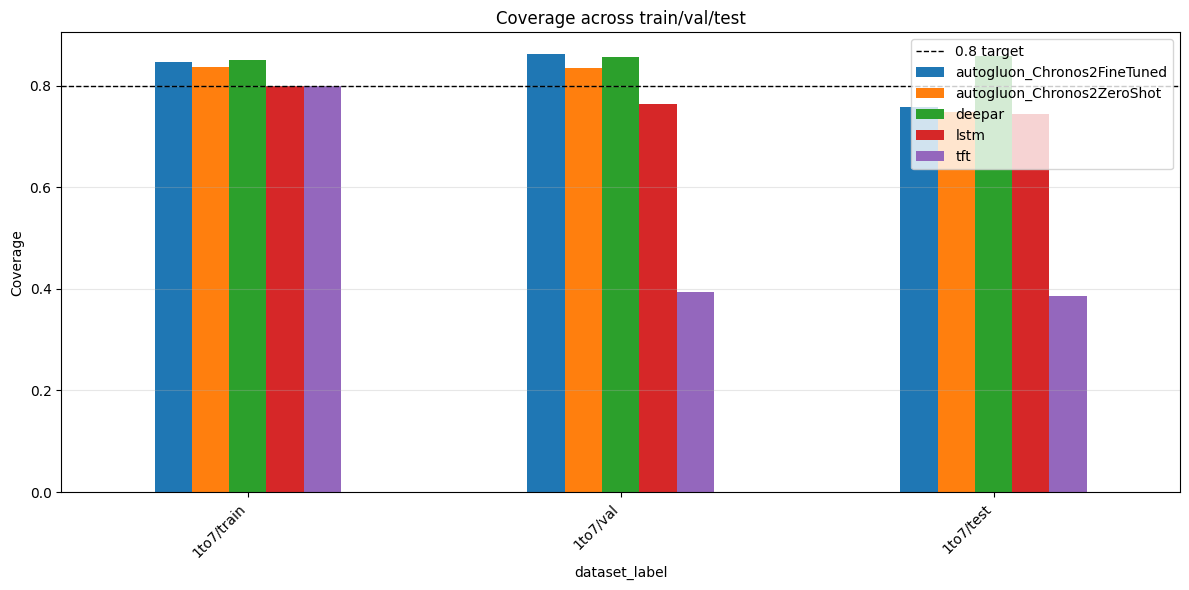

model            autogluon_Chronos2FineTuned  autogluon_Chronos2ZeroShot
dataset   split                                                         
data_1to7 test                      5.507745                    5.467941
          train                     3.813376                    3.816793
          val                       4.913559                    4.801247

In [5]:
summary_df = pd.concat(
    [train_df, autogluon_df[["dataset", "split", "model", "coverage"]]],
    ignore_index=True,
)
summary_df["dataset_label"] = summary_df["dataset"].str.replace("data_", "") + "/" + summary_df["split"]
order = [
    "1to7/train",
    "1to7/val",
    "1to7/test",
]

summary_pivot = summary_df.pivot_table(
    index="dataset_label", columns="model", values="coverage"
).reindex(order)
summary_pivot  # type: ignore

ax = summary_pivot.plot(kind="bar", figsize=(12, 6))
ax.axhline(COVERAGE_TARGET, color="black", linestyle="--", linewidth=1, label="0.8 target")
ax.set_ylabel("Coverage")
ax.set_title("Coverage across train/val/test")
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=45, ha="right")
ax.legend()
plt.tight_layout()
plt.show()

autogluon_rmse_pivot
